In [ ]:
!pip install -U datasets fsspec

In [ ]:
# Install the datasets library if needed
!pip install datasets

from datasets import load_dataset

# Load the HELOC dataset (binary classification task)
dataset = load_dataset("mstz/heloc")["train"]


In [ ]:
import torch
import numpy as np
from typing import cast, List, Optional, Union
from tqdm import tqdm
import pandas as pd
import seaborn as sns
import time
import math
import torch.nn as nn

from torch.optim import Optimizer

In [ ]:
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim, output_dim=2, seed=100):
        super().__init__()
        if seed is not None:
            torch.manual_seed(seed)
        self.linear = nn.Linear(input_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.linear(x))

# class BatchNormClassifier(nn.Module):
#     def __init__(self, input_dim, hidden_dims=[256, 128, 64], output_dim=2, seed=100):
#         super().__init__()
#         if seed is not None:
#             torch.manual_seed(seed)

#         layers = []
#         prev_dim = input_dim

#         for hidden_dim in hidden_dims:
#             layers.extend([
#                 nn.Linear(prev_dim, hidden_dim),
#                 nn.BatchNorm1d(hidden_dim),
#                 nn.ReLU(),
#                 nn.Dropout(0.2)
#             ])
#             prev_dim = hidden_dim

#         layers.append(nn.Linear(prev_dim, output_dim))
#         self.network = nn.Sequential(*layers)

#     def forward(self, x):
#         return self.network(x)


In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

def train_model_stochastic(model, optimizer, criterion, results, X_train, y_train, X_test, y_test,
                          num_epochs, opt_name, lr, batch_size=32, shuffle=True, time_start=None,
                          r=None, use_tqdm=True, grad_save_dir='gradients'):
    """
    Train a model using stochastic gradient descent with mini-batches and evaluate on test data.

    Args:
        batch_size (int): Size of mini-batches for stochastic training
        shuffle (bool): Whether to shuffle training data each epoch
    """
    from tqdm import tqdm
    import time

    # Create directory for saving gradients
    if not os.path.exists(grad_save_dir):
        os.makedirs(grad_save_dir)

    # Create DataLoader for stochastic training
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle)

    epoch_iterator = tqdm(range(num_epochs)) if use_tqdm else range(num_epochs)

    if time_start is None:
        time_start = time.time()

    for epoch in epoch_iterator:
        model.train()
        start_epoch = time.time()
        epoch_loss = 0.0
        num_batches = 0

        # Stochastic training loop over mini-batches
        for batch_idx, (batch_X, batch_y) in enumerate(train_loader):
            optimizer.zero_grad()

            # Forward pass on mini-batch
            y_pred = model(batch_X)
            batch_loss = criterion(y_pred, batch_y)

            # Backward pass
            batch_loss.backward()

            # Save gradients from the last batch of each epoch
            if batch_idx == len(train_loader) - 1:
                grad_dict = {}
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        grad_dict[name] = param.grad.detach().cpu().numpy()

                # Save gradients to compressed numpy file per epoch
                grad_filename = f'{opt_name}_lr{lr}_epoch{epoch}'
                if r is not None:
                    grad_filename += f'_rank{r}'
                grad_file = os.path.join(grad_save_dir, f'{grad_filename}.npz')
                np.savez_compressed(grad_file, **grad_dict)

            # Update parameters
            optimizer.step()

            epoch_loss += batch_loss.item()
            num_batches += 1

        # Calculate average loss for the epoch
        avg_train_loss = epoch_loss / num_batches

        elapsed_time = time.time() - time_start
        epoch_time = time.time() - start_epoch
        avg_epoch_time = elapsed_time / (epoch + 1)

        if r is not None:
            r_in_name = f" rank {r}"
        else:
            r_in_name = ''

        results.append({
            'epoch': epoch,
            'optimizer': opt_name + f"{r_in_name}",
            'lr': lr,
            'loss': avg_train_loss,
            'rank': r,
            'avg_epoch_time': avg_epoch_time,
            'epoch_time': epoch_time,
            'batch_size': batch_size
        })

    # Final evaluation on test set
    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test)
        test_loss = criterion(y_pred_test, y_test).item()

    return results, test_loss


In [ ]:
import os
import numpy as np
import torch

def train_model(model, optimizer, criterion, results, X_train, y_train, X_test, y_test,
                num_epochs, opt_name, lr, time_start=None, r=None, use_tqdm=True, grad_save_dir='gradients'):
    """
    Train a model and evaluate on test data, saving gradients by epoch.
    """
    from tqdm import tqdm
    import time

    # Create directory for saving gradients
    if not os.path.exists(grad_save_dir):
        os.makedirs(grad_save_dir)

    epoch_iterator = tqdm(range(num_epochs)) if use_tqdm else range(num_epochs)

    if time_start is None:
        time_start = time.time()

    for epoch in epoch_iterator:
        model.train()
        start_epoch = time.time()
        optimizer.zero_grad()
        y_pred = model(X_train)
        train_loss = criterion(y_pred, y_train)
        train_loss.backward()

        # Access and save gradients after backward() but before optimizer.step()
        grad_dict = {}
        for name, param in model.named_parameters():
            if param.grad is not None:
                grad_dict[name] = param.grad.detach().cpu().numpy()

        # Save gradients to compressed numpy file per epoch
        grad_filename = f'{opt_name}_lr{lr}_epoch{epoch}'
        if r is not None:
            grad_filename += f'_rank{r}'
        grad_file = os.path.join(grad_save_dir, f'{grad_filename}.npz')
        np.savez_compressed(grad_file, **grad_dict)

        optimizer.step()

        elapsed_time = time.time() - time_start
        epoch_time = time.time() - start_epoch

        avg_epoch_time = elapsed_time / (epoch + 1)

        if r is not None:
            r_in_name = f" rank {r}"
        else:
            r_in_name = ''

        results.append({
            'epoch': epoch,
            'optimizer': opt_name + f"{r_in_name}",
            'lr': lr,
            'batch_size': bs,
            'loss': train_loss.detach().cpu().numpy(),
            'rank': r,
            'avg_epoch_time': avg_epoch_time,
            'epoch_time': epoch_time
        })

    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test)
        test_loss = criterion(y_pred_test, y_test).item()

    return results, test_loss


In [ ]:
def load_heloc_data():
    """Load HELOC dataset from Kaggle or alternative source"""
    import kagglehub
    import pandas as pd
    from sklearn.preprocessing import StandardScaler
    import torch

    try:
        # Try downloading from Kaggle
        from datasets import load_dataset

        heloc_dataset = load_dataset("mstz/heloc")
        heloc_df = pd.DataFrame(heloc_dataset["train"])
    except:
        # Fallback: Load from a direct URL or manual download
        print("Please download HELOC dataset manually")
        return None, None, None

    # Handle missing values
    heloc_df = heloc_df.fillna(heloc_df.median(numeric_only=True))

    # Prepare features and target
    X = heloc_df.drop(columns=['is_at_risk']).values
    y = heloc_df['is_at_risk'].values

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Convert to torch tensors
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)

    return X_tensor, y_tensor


In [ ]:
def load_uci()
  !pip install ucimlrepo

  # Method 1: Using UCI ML Repository
  from ucimlrepo import fetch_ucirepo
  import pandas as pd

  # Fetch the dataset
  bank_marketing = fetch_ucirepo(id=222)
  df = pd.DataFrame(bank_marketing.data.features)
  df['target'] = bank_marketing.data.targets

  X = df.drop(columns=['target'])
  y = df['target']

  return X, y

# Basic exploration
print(f"Dataset shape: {df.shape}")
print(f"Target distribution: {df['target'].value_counts()}")


SyntaxError: expected ':' (<ipython-input-7-2520954580>, line 1)

In [ ]:
!pip install kagglehub

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from datasets import load_dataset
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from adagram_fixed_rank import AdaGramFR
import kagglehub


torch.manual_seed(42)
np.random.seed(42)

def load_income_data():
    """Load and preprocess Adult Income dataset for binary classification"""
    # Load the dataset
    path = kagglehub.dataset_download("wenruliu/adult-income-dataset")
    income_df = pd.read_csv(os.path.join(path, 'adult.csv'))
    return income_df


def process_income_data():
    """Load and preprocess Adult Income dataset for binary classification"""
    # Load the dataset
    load_income_data()
    income_df = pd.read_csv('/kaggle/input/adult-income-dataset/adult.csv')

    # 1. Handle missing values FIRST
    income_df = income_df.replace('?', np.nan)
    categorical_cols = ['workclass', 'occupation', 'native-country']
    for col in categorical_cols:
        if col in income_df.columns:
            income_df[col].fillna(income_df[col].mode()[0])

    # 2. Encode categorical variables BEFORE scaling
    # Updated column names to match your dataset
    categorical_features = ['workclass', 'education', 'marital-status', 'occupation',
                           'relationship', 'race', 'gender', 'native-country']  # Changed 'sex' to 'gender'

    for col in categorical_features:
        if col in income_df.columns:
            le = LabelEncoder()
            income_df[col] = le.fit_transform(income_df[col])

    # 3. Encode target variable
    target_encoder = LabelEncoder()
    income_df['income_encoded'] = target_encoder.fit_transform(income_df['income'])

    # 4. NOW prepare features and target (all numerical)
    X = income_df.drop(columns=['income', 'income_encoded']).values
    y = income_df['income_encoded'].values

    # 5. Scale features (now all numerical) - Fixed to use X_scaled
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 6. Convert to torch tensors - Fixed to use X_scaled instead of X
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)  # Use scaled features
    y_tensor = torch.tensor(y, dtype=torch.long)

    return X_tensor, y_tensor  # Return tensors, not numpy arrays


# Configuration
learning_rates = [0.1]
num_epochs = 300
ranks = [3]
batch_sizes = [10]

# Load HELOC data instead of toy data
# X, y = load_heloc_data()
X, y = process_income_data()
in_dims = [X.shape[1]]  # Use actual feature dimension (23 features)
out_dims = [2]  # Binary classification

print(f"Dataset shape: {X.shape}, Target shape: {y.shape}")
print("Condition number:", torch.linalg.cond(X))

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define optimizers
optimizers = {
    'AdaGramFR_nosvd': lambda params, lr, max_rank: AdaGramFR(params, lr=lr, max_rank=max_rank),
}

models = {}
all_train_losses = {}
all_test_losses = {}
results = []

# Training loop
for opt_name, opt_fn in optimizers.items():
    for lr in learning_rates:
      for bs in batch_sizes:
        criterion = nn.CrossEntropyLoss()
        print(f"Training with {opt_name}")

        if opt_name == "AdaGramFR":
            for rank in ranks:
                model = SimpleClassifier(input_dim=in_dims[0], output_dim=out_dims[0], seed=100)
                optimizer = opt_fn(model.parameters(), lr, max_rank=rank)
                epoch_results, test_loss = train_model_stochastic(
                    model=model,
                    optimizer=optimizer,
                    criterion=criterion,
                    results=results,
                    X_train=X_train,
                    y_train=y_train,
                    X_test=X_test,
                    y_test=y_test,
                    num_epochs=num_epochs,
                    opt_name=opt_name,
                    lr=lr,
                    r=rank,
                    batch_size=bs
                )
        else:
            model = SimpleClassifier(input_dim=in_dims[0], output_dim=out_dims[0], seed=100)
            optimizer = opt_fn(model.parameters(), lr)
            epoch_results, test_loss = train_model_stochastic(
                model=model,
                optimizer=optimizer,
                criterion=criterion,
                results=results,
                X_train=X_train,
                y_train=y_train,
                X_test=X_test,
                y_test=y_test,
                num_epochs=num_epochs,
                opt_name=opt_name,
                lr=lr,
                batch_size=bs
            )

# Save results
df = pd.DataFrame(results)
df['loss'] = df['loss'].astype(float)
df.to_csv(f'income_benchmark_stoch_svd_{in_dims[0]}_features.csv')
print(f"Results saved for Income dataset with {in_dims[0]} features")


Dataset shape: torch.Size([48842, 14]), Target shape: torch.Size([48842])
Condition number: tensor(2.3072)
Training with AdaGramFR


100%|██████████| 300/300 [37:03<00:00,  7.41s/it]


Training with Vanilla_SGD


100%|██████████| 300/300 [09:37<00:00,  1.92s/it]


Training with Torch_Adagrad


100%|██████████| 300/300 [11:07<00:00,  2.22s/it]


Training with Adam


100%|██████████| 300/300 [12:27<00:00,  2.49s/it]

Results saved for Income dataset with 14 features


In [ ]:
df_1 = pd.read_csv('/content/income_benchmark_stoch_14_features.csv')
df_2 = pd.read_csv('/content/income_benchmark_stoch_all_other_14_features.csv')

df = pd.concat([df_1, df_2])

Plot saved to: logregIncome stochastic(14, 2)_comparison_plot.pdf


<Figure size 1500x1500 with 0 Axes>

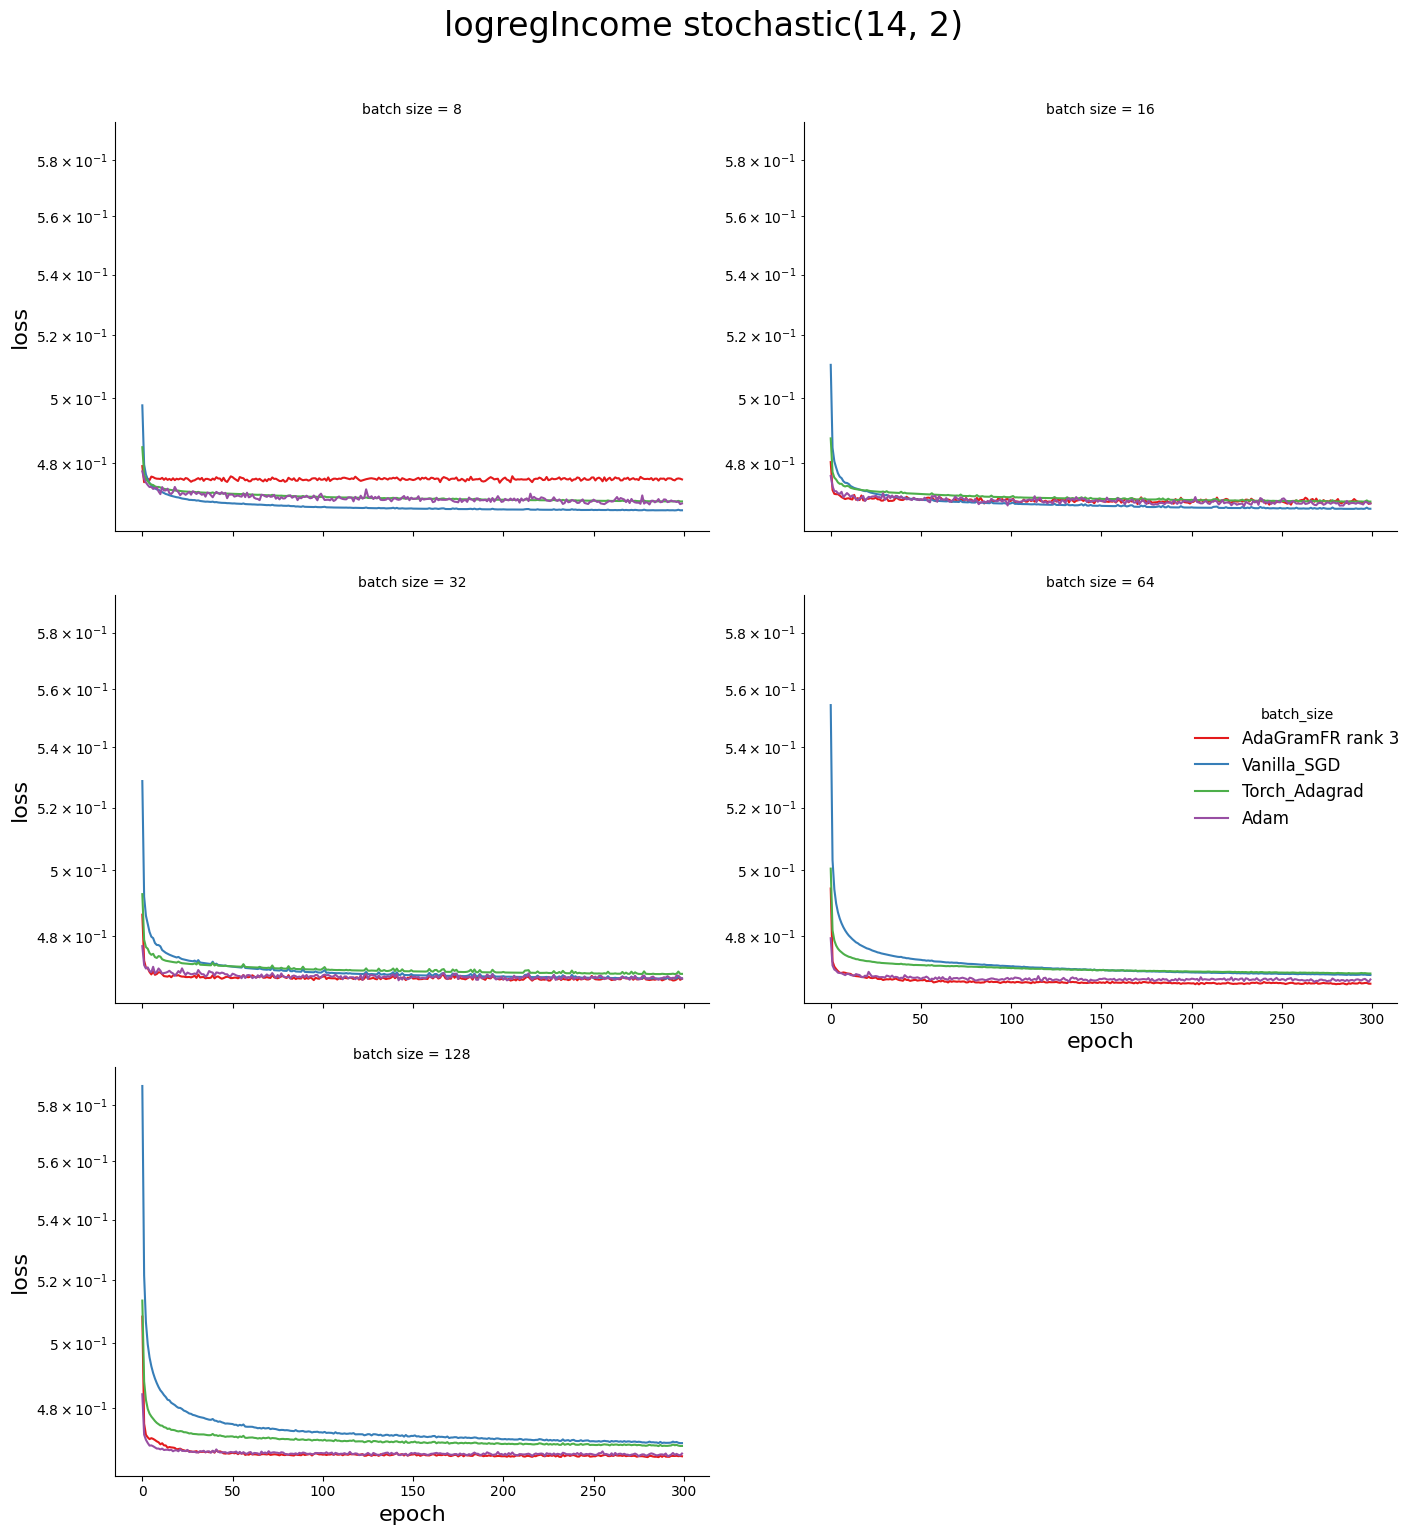

In [ ]:
name = 'logregIncome stochastic'

plt.figure(figsize=(15, 15))
grid = sns.FacetGrid(
    data=df,
    col='batch_size',
    height=5,
    col_wrap=2,
    aspect=1.2,
    sharey=True
)

grid.map_dataframe(
    sns.lineplot,
    x='epoch',
    y='loss',
    hue='optimizer',
    palette='Set1',
    linewidth=1.5
)

# Set bigger font size for legend title and legend text
grid.add_legend(title='batch_size', title_fontsize='15', fontsize='12')

grid.fig.suptitle(f'{name}({in_dims[0]}, {out_dims[0]})',
                  fontsize=24, y=1.02)

# Set bigger font size for axis labels
for ax in grid.axes.flat:
    ax.set_yscale('log')
    ax.set_xlabel(ax.get_xlabel(), fontsize=16)
    ax.set_ylabel(ax.get_ylabel(), fontsize=16)

grid.set_titles(col_template="batch size = {col_name}", fontsize=22)

plt.tight_layout()
pdf_path = f'{name}({in_dims[0]}, {out_dims[0]})_comparison_plot.pdf'
grid.savefig(pdf_path, bbox_inches='tight', dpi=300)
print(f"Plot saved to: {pdf_path}")

plt.show()